In [124]:
from atomica.models import MultiClassClassifierModel, MultiLabelClassifierModel, ResidueClassifierModel
from atomica.data.dataset import MultiClassLabelledPDBDataset, LabelledPDBDataset
from atomica.trainers import Trainer

from multiclass_metrics import compute_multiclass_metrics
from multilabel_metrics import compute_multilabel_metrics

from torch.utils.data import DataLoader
import torch
from tqdm import tqdm
import numpy as np
import pandas as pd
import json
import os
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context("notebook")
custom_colors = ['#7B2EF7', '#26CFC0', '#E65AFA', '#078C95', '#133693', '#7EB4FF']

DATA_DIR="/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_tasks"
MODEL_DIR="/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark"

In [70]:
def process_atomica_rnafm_mlp_results(results_dir: str, val_metric: str, exclude_dropout: bool = False) -> pd.DataFrame:
    results = []
    for version in os.listdir(results_dir):
        if not version.startswith("version_"):
            continue
        for seed in os.listdir(os.path.join(results_dir, version)):
            if not seed.startswith("seed_"):
                continue
            if exclude_dropout and "dropout" in version:
                dropout_idx = version.split("_").index("dropout") + 1
                dropout_val = float(version.split("_")[dropout_idx])
                if dropout_val > 0:
                    continue
            with open(os.path.join(results_dir, version, seed, "training_history.json"), "r") as f:
                training_history = json.load(f)
            val_metric_value = training_history[val_metric]
            results.append({
                "version": version,
                "seed": seed,
                "val_metric": val_metric_value,
            })
    df = pd.DataFrame(results)
    ave_df = df.groupby('version')[['val_metric']].mean()
    ave_df.sort_values(by='val_metric', ascending=False, inplace=True)
    
    test_results = []
    best_version = ave_df.index[0]
    for seed in os.listdir(os.path.join(results_dir, best_version)):
        test_metrics_path = os.path.join(results_dir, best_version, seed, "test_metrics.json")
        with open(test_metrics_path, "r") as f:
            test_metrics = json.load(f)
        test_metrics['version'] = best_version
        test_metrics['seed'] = seed
        test_results.append(test_metrics)
    return pd.DataFrame(test_results)

def get_model(model_checkpoint: str, task_name: str) -> str:
    model_config = os.path.join(os.path.dirname(model_checkpoint), "config.json")
    if task_name == "RNAGo":
        return MultiLabelClassifierModel.load_from_config_and_weights(model_config, model_checkpoint)
    elif task_name == "RNA_Ligand":
        return MultiClassClassifierModel.load_from_config_and_weights(model_config, model_checkpoint)
    elif task_name == "RNA_Protein" or task_name == "RNA_Site":
        return ResidueClassifierModel.load_from_config_and_weights(model_config, model_checkpoint)
    else:
        raise ValueError(f"Task name {task_name} not supported")

def get_atomica_results(model_checkpoint, task_name, split="val", threshold=0.5):
    if os.path.exists(os.path.join(os.path.dirname(model_checkpoint), f"{split}_atomica_results.parquet")):
        return pd.read_parquet(os.path.join(os.path.dirname(model_checkpoint), f"{split}_atomica_results.parquet"))
    atomica_preds = []
    dataset = MultiClassLabelledPDBDataset(f"{DATA_DIR}/{task_name}/{task_name}_{split}_processed.parquet")
    model = get_model(model_checkpoint, task_name)

    model.eval()
    model.to("cuda")
    batch_size = 1
    for i in tqdm(range(0, len(dataset), batch_size), total=len(dataset) // batch_size):
        with torch.no_grad():
            batch = [dataset[j] for j in range(i, min(i+batch_size, len(dataset)))]
            batch = MultiClassLabelledPDBDataset.collate_fn(batch)
            batch = Trainer.to_device(batch, "cuda")
            atomica_preds.append(model.infer(batch).cpu().numpy())
    atomica_preds = np.concatenate(atomica_preds)
    if task_name == "RNA_Protein":
        atomica_labels = np.concatenate([x['label'] for x in dataset.data])
        atomica_ids = sum([[x['id']] * len(x['label']) for x in dataset.data], [])
        atomica_preds = atomica_preds.flatten()
    elif task_name == "RNA_Site":
        atomica_labels = np.concatenate([x['label'] for x in dataset.data])
        atomica_preds = atomica_preds.flatten()
        atomica_ids = []
        for x in dataset.data:
            assert len(x['label']) == len(x['block_to_pdb_indexes'])
            for _, pdb_index in sorted(x['block_to_pdb_indexes'].items()):
                atomica_ids.append(x['id'] + '_' + str(pdb_index))
    else:
        atomica_labels = np.array([x['label'] for x in dataset.data])
        atomica_ids = np.array([x['id'] for x in dataset.data])
    atomica_results = pd.DataFrame({
        'id': atomica_ids,
        'label': atomica_labels,
        'pred_probability': atomica_preds,
    })
    if task_name == "RNA_Ligand":
        atomica_results['pred'] = atomica_results['pred_probability'].apply(lambda x: np.argmax(x))
    elif task_name == "RNAGo":
        atomica_results['pred'] = atomica_results['pred_probability'].apply(lambda x: (x > threshold).astype(int))
    else:
        atomica_results['pred'] = (atomica_results['pred_probability'] > threshold).astype(int)

    atomica_results.to_parquet(os.path.join(os.path.dirname(model_checkpoint), f"{split}_atomica_results.parquet"))
    return atomica_results

# RNAGo
Not SOTA

In [102]:
baselines = []
for baseline_model in ["rinalmo","rnafm","rnaernie"]:
    df = process_atomica_rnafm_mlp_results(f"{DATA_DIR}/{baseline_model}/RNAGo/", "best_val_f1")
    df['baseline_model'] = baseline_model
    baselines.append(df)
baselines = pd.concat(baselines)
baseline_agg_results = baselines.groupby('baseline_model').agg({
    'subset_accuracy': ['mean', 'std'],
    'f1_macro': ['mean', 'std'],
    'f1_micro': ['mean', 'std'],
    'f1_weighted': ['mean', 'std'],
})
baseline_agg_results

subset_accuracy            f1_macro            f1_micro  \
                          mean       std      mean       std      mean   
baseline_model                                                           
rinalmo               0.893333  0.023094  0.859179  0.011015  0.891039   
rnaernie              0.728889  0.007698  0.613292  0.025704  0.676667   
rnafm                 0.831111  0.027756  0.715697  0.009991  0.775113   

                         f1_weighted            
                     std        mean       std  
baseline_model                                  
rinalmo         0.021107    0.894595  0.023435  
rnaernie        0.021225    0.656069  0.019522  
rnafm           0.010831    0.792137  0.007553

In [4]:
baselines

,subset_accuracy,f1_macro,f1_micro,f1_weighted,f1_samples,jaccard_macro,jaccard_micro,jaccard_weighted,jaccard_samples,roc_auc_ovr_macro,roc_auc_ovr_weighted,roc_auc_ovr_micro,per_label,per_label_ovr_auc,version,seed,baseline_model
0,0.906667,0.865538,0.903226,0.908125,0.453333,0.779091,0.823529,0.836557,0.453333,0.992102,0.987276,0.975934,"{'0': {'precision': 0.7272727272727273, 'recal...","{'0': 1.0, '1': 1.0, '2': 0.9786931818181819, ...",version_lr_1e-3_dropout_0.4_hidden_dim_256,seed_0,rinalmo
1,0.866667,0.846460,0.866667,0.867534,0.413333,0.749091,0.764706,0.772727,0.413333,0.990625,0.980325,0.978594,"{'0': {'precision': 0.7272727272727273, 'recal...","{'0': 1.0, '1': 1.0, '2': 0.9985795454545454, ...",version_lr_1e-3_dropout_0.4_hidden_dim_256,seed_1,rinalmo
2,0.906667,0.865538,0.903226,0.908125,0.453333,0.779091,0.823529,0.836557,0.453333,0.997250,0.994693,0.988713,"{'0': {'precision': 0.7272727272727273, 'recal...","{'0': 1.0, '1': 1.0, '2': 0.9971590909090909, ...",version_lr_1e-3_dropout_0.4_hidden_dim_256,seed_2,rinalmo
0,0.800000,0.707272,0.762887,0.786402,0.377778,0.578209,0.616667,0.662547,0.373333,0.989966,0.985995,0.964907,"{'0': {'precision': 0.47058823529411764, 'reca...","{'0': 1.0, '1': 1.0, '2': 0.9616477272727273, ...",version_lr_1e-3_dropout_0.1_hidden_dim_1024,seed_0,rnafm
1,0.853333,0.726735,0.778947,0.789314,0.386667,0.587980,0.637931,0.660520,0.386667,0.993943,0.990649,0.966853,"{'0': {'precision': 0.5333333333333333, 'recal...","{'0': 1.0, '1': 1.0, '2': 0.9815340909090909, ...",version_lr_1e-3_dropout_0.1_hidden_dim_1024,seed_1,rnafm
2,0.840000,0.713085,0.783505,0.800696,0.400000,0.581313,0.644068,0.680024,0.400000,0.999148,0.999003,0.980605,"{'0': {'precision': 0.5333333333333333, 'recal...","{'0': 1.0, '1': 1.0, '2': 0.9957386363636364, ...",version_lr_1e-3_dropout_0.1_hidden_dim_1024,seed_2,rnafm
0,0.720000,0.583709,0.652174,0.653545,0.293333,0.467619,0.483871,0.524569,0.293333,0.965243,0.948973,0.938505,"{'0': {'precision': 0.5714285714285714, 'recal...","{'0': 0.9850746268656716, '1': 0.9957983193277...",version_lr_1e-3_dropout_0.0_hidden_dim_64,seed_0,rnaernie
1,0.733333,0.630159,0.688172,0.676731,0.320000,0.501120,0.524590,0.538349,0.320000,0.952369,0.928279,0.887001,"{'0': {'precision': 0.6153846153846154, 'recal...","{'0': 0.9832089552238806, '1': 0.9978991596638...",version_lr_1e-3_dropout_0.0_hidden_dim_64,seed_1,rnaernie
2,0.733333,0.626007,0.689655,0.637932,0.293333,0.509848,0.526316,0.521841,0.293333,0.964381,0.947713,0.926959,"{'0': {'precision': 0.6666666666666666, 'recal...","{'0': 0.9944029850746269, '1': 0.9978991596638...",version_lr_1e-3_dropout_0.0_hidden_dim_64,seed_2,rnaernie


In [ ]:
# model_checkpoint = f"{MODEL_DIR}/RNAGo/models/version_22/checkpoint/epoch118_step18207.pt"
# model_checkpoint = f"{MODEL_DIR}/RNAGo/models/version_17/checkpoint/epoch294_step45135.pt"
# model_checkpoint = f"{MODEL_DIR}/RNAGo/models/version_28/checkpoint/epoch362_step55539.pt" # SOTA 

# grad clip 0.5, lr 2e-5
# model_checkpoint = f"{MODEL_DIR}/RNAGo/models/version_42/checkpoint/epoch164_step25245.pt" # SOTA 3, lowest val loss
# model_checkpoint = f"{MODEL_DIR}/RNAGo/models/version_45/checkpoint/epoch181_step27118.pt" 
# model_checkpoint = f"{MODEL_DIR}/RNAGo/models/version_57/checkpoint/epoch293_step44982.pt"


test_metrics = []
val_metrics = []

# grad clip 1.0, lr 2e-5
checkpoint_paths = [
    f"{MODEL_DIR}/RNAGo/models/version_32/checkpoint/epoch173_step26622.pt", # SOTA 2, lowest val loss
    f"{MODEL_DIR}/RNAGo/models/version_49/checkpoint/epoch217_step32918.pt",
    f"{MODEL_DIR}/RNAGo/models/version_50/checkpoint/epoch233_step35100.pt",
]

# # grad clip 0.5, lr 2e-5
# checkpoint_paths = [
#     f"{MODEL_DIR}/RNAGo/models/version_42/checkpoint/epoch164_step25245.pt", # SOTA 3, lowest val loss
#     f"{MODEL_DIR}/RNAGo/models/version_53/checkpoint/epoch294_step44840.pt",
#     f"{MODEL_DIR}/RNAGo/models/version_57/checkpoint/epoch293_step44982.pt",
# ]

ensemble_test_prob = None
ensemble_val_prob = None
for checkpoint_path in checkpoint_paths:
    atomica_results_val = get_atomica_results(checkpoint_path, "RNAGo", split="val")
    atomica_results_test = get_atomica_results(checkpoint_path, "RNAGo", split="test")

    best_f1_threshold = 0.0
    best_f1_score = 0.0
    f1_thresholds = np.linspace(0.0, 0.5, 6)
    for threshold in f1_thresholds:
        metrics = compute_multilabel_metrics(
            y_true=np.stack(atomica_results_val['label']),
            y_proba=np.stack(atomica_results_val['pred_probability']),
            threshold=threshold
        )
        if metrics.f1_weighted > best_f1_score:
            best_f1_score = metrics.f1_weighted
            best_f1_threshold = threshold

    metrics = compute_multilabel_metrics(
        y_true=np.stack(atomica_results_test['label']),
        y_proba=np.stack(atomica_results_test['pred_probability']),
        threshold=best_f1_threshold
    )
    if ensemble_test_prob is None:
        ensemble_test_prob = atomica_results_test['pred_probability']
        ensemble_val_prob = atomica_results_val['pred_probability']
    else:
        ensemble_test_prob += atomica_results_test['pred_probability']
        ensemble_val_prob += atomica_results_val['pred_probability']
    test_metrics.append({
        "checkpoint_path": checkpoint_path,
        "subset_accuracy": metrics.subset_accuracy,
        "f1_macro": metrics.f1_macro,
        "f1_micro": metrics.f1_micro,
        "f1_weighted": metrics.f1_weighted,
    })

    metrics = compute_multilabel_metrics(
        y_true=np.stack(atomica_results_val['label']),
        y_proba=np.stack(atomica_results_val['pred_probability']),
        threshold=best_f1_threshold
    )
    val_metrics.append({
        "checkpoint_path": checkpoint_path,
        "subset_accuracy": metrics.subset_accuracy,
        "f1_macro": metrics.f1_macro,
        "f1_micro": metrics.f1_micro,
        "f1_weighted": metrics.f1_weighted,
    })

test_metrics = pd.DataFrame(test_metrics)
val_metrics = pd.DataFrame(val_metrics)
test_metrics['split'] = 'atomica'
val_metrics['split'] = 'atomica-val'
all_metrics = pd.concat([test_metrics, val_metrics])
all_metrics = all_metrics.groupby('split').agg({
    'subset_accuracy': ['mean', 'std'],
    'f1_macro': ['mean', 'std'],
    'f1_micro': ['mean', 'std'],
    'f1_weighted': ['mean', 'std'],
})
display(all_metrics)


# Ensemble the seeds is not useful for this task
ensemble_test_prob = np.stack(ensemble_test_prob) / len(checkpoint_paths)
ensemble_val_prob = np.stack(ensemble_val_prob) / len(checkpoint_paths)

best_f1_threshold = 0.0
best_f1_score = 0.0
f1_thresholds = np.linspace(0.0, 0.5, 6)
for threshold in f1_thresholds:
    metrics = compute_multilabel_metrics(
        y_true=np.stack(atomica_results_val['label']),
        y_proba=ensemble_val_prob,
        threshold=threshold
    )
    if metrics.f1_weighted > best_f1_score:
        best_f1_score = metrics.f1_weighted
        best_f1_threshold = threshold

ensemble_metrics = compute_multilabel_metrics(
    y_true=np.stack(atomica_results_test['label']),
    y_proba=np.stack(ensemble_test_prob),
    threshold=best_f1_threshold
)
print(ensemble_metrics)

subset_accuracy            f1_macro            f1_micro            \
                       mean       std      mean       std      mean       std   
split                                                                           
atomica            0.626667  0.144222  0.699329  0.044696  0.722888  0.094032   
atomica-val        0.737778  0.060123  0.770707  0.042771  0.862488  0.019693   

            f1_weighted            
                   mean       std  
split                              
atomica        0.821226  0.044890  
atomica-val    0.894926  0.014306

MultilabelMetricsResult(subset_accuracy=0.48, f1_macro=0.6730598290598291, f1_micro=0.6515151515151515, f1_weighted=0.8115693762502274, f1_samples=0.45466666666666666, jaccard_macro=0.5981601731601731, jaccard_micro=0.48314606741573035, jaccard_weighted=0.7402482269503547, jaccard_samples=0.44888888888888884, roc_auc_ovr_macro=0.9996363636363637, roc_auc_ovr_weighted=0.9992263056092844, roc_auc_ovr_micro=0.9690581214322782, per_label={0: {'precision': 0.19047619047619047, 'recall': 1.0, 'f1': 0.32, 'support': 8.0, 'jaccard': 0.19047619047619047}, 1: {'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'support': 7.0, 'jaccard': 1.0}, 2: {'precision': 1.0, 'recall': 0.8181818181818182, 'f1': 0.9, 'support': 11.0, 'jaccard': 0.8181818181818182}, 3: {'precision': 0.125, 'recall': 1.0, 'f1': 0.2222222222222222, 'support': 1.0, 'jaccard': 0.125}, 4: {'precision': 0.9473684210526315, 'recall': 0.9, 'f1': 0.9230769230769231, 'support': 20.0, 'jaccard': 0.8571428571428571}}, per_label_ovr_auc={0: 1.0,

### Ensemble model

In [101]:
# Use best val f1 as metric
# TODO: rerun this, this is running with the new RNAFM model
ensemble_df = process_atomica_rnafm_mlp_results(
    "/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/atomica_ensemble/RNAGo/no_normalize_l2_no_use_layer_norm/",
    "best_val_f1"
)
ensemble_df['model'] = 'ensemble'
ensemble_df = ensemble_df.groupby('model').agg({
    'subset_accuracy': ['mean', 'std'],
    'f1_macro': ['mean', 'std'],
    'f1_micro': ['mean', 'std'],
    'f1_weighted': ['mean', 'std'],
})

In [32]:
ensemble_df

subset_accuracy            f1_macro            f1_micro           \
                    mean       std      mean       std      mean      std   
model                                                                       
ensemble        0.897778  0.033555  0.866029  0.019447  0.892036  0.02863   

         f1_weighted            
                mean       std  
model                           
ensemble    0.892307  0.029533

In [26]:
results = pd.concat([baseline_agg_results, all_metrics, ensemble_df])
results.reset_index(inplace=True)
results.rename(columns={'index': 'model'}, inplace=True)
results = results[results['model'] != 'atomica-val']

# RNA Ligand

Not SOTA

In [33]:
baselines = []
for baseline_model in ["rinalmo","rnafm","rnaernie"]:
    df = process_atomica_rnafm_mlp_results(f"{DATA_DIR}/{baseline_model}/RNA_Ligand/", "best_val_f1")
    df['baseline_model'] = baseline_model
    baselines.append(df)
baselines = pd.concat(baselines)
baseline_agg_results = baselines.groupby('baseline_model').agg({
    'accuracy': ['mean', 'std'],
    'balanced_accuracy': ['mean', 'std'],
    'f1_macro': ['mean', 'std'],
    'f1_micro': ['mean', 'std'],
    'f1_weighted': ['mean', 'std'],
})
baseline_agg_results

accuracy           balanced_accuracy            f1_macro  \
                    mean       std              mean       std      mean   
baseline_model                                                             
rinalmo         0.810606  0.026243          0.882375  0.025556  0.797815   
rnaernie        0.901515  0.112111          0.832567  0.194740  0.801715   
rnafm           0.901515  0.013122          0.942912  0.010925  0.904183   

                          f1_micro           f1_weighted            
                     std      mean       std        mean       std  
baseline_model                                                      
rinalmo         0.035177  0.810606  0.026243    0.819923  0.024574  
rnaernie        0.238956  0.901515  0.112111    0.891819  0.129720  
rnafm           0.014558  0.901515  0.013122    0.906021  0.011833

In [38]:
baselines

,accuracy,balanced_accuracy,f1_macro,f1_micro,f1_weighted,jaccard_macro,jaccard_micro,jaccard_weighted,roc_auc_ovr_macro,roc_auc_ovr_weighted,roc_auc_ovo_macro,roc_auc_ovo_weighted,per_class,per_class_ovr_auc,version,seed,baseline_model
0,0.795455,0.896552,0.813234,0.795455,0.803677,0.692848,0.660377,0.675505,0.982291,0.987862,0.975862,0.982132,"{'0': {'precision': 0.5555555555555556, 'recal...","{'0': 0.9794117647058824, '1': 0.9931034482758...",version_lr_1e-4_dropout_0.0_hidden_dim_64,seed_0,rinalmo
1,0.795455,0.852874,0.757561,0.795455,0.807899,0.615837,0.660377,0.684343,0.941655,0.962896,0.945172,0.949510,"{'0': {'precision': 0.6153846153846154, 'recal...","{'0': 0.8705882352941177, '1': 0.9954022988505...",version_lr_1e-4_dropout_0.0_hidden_dim_64,seed_1,rinalmo
2,0.840909,0.897701,0.822650,0.840909,0.848193,0.702463,0.725490,0.740260,0.962196,0.964881,0.970920,0.966987,"{'0': {'precision': 0.6428571428571429, 'recal...","{'0': 0.9147058823529411, '1': 0.9770114942528...",version_lr_1e-4_dropout_0.0_hidden_dim_64,seed_2,rinalmo
0,0.909091,0.954023,0.919753,0.909091,0.913300,0.858785,0.833333,0.844156,0.991304,0.990683,0.989770,0.989910,"{'0': {'precision': 0.7142857142857143, 'recal...","{'0': 0.9882352941176471, '1': 0.9908045977011...",version_lr_1e-4_dropout_0.0_hidden_dim_512,seed_0,rnafm
1,0.886364,0.942529,0.901887,0.886364,0.892367,0.831418,0.795918,0.810606,0.972819,0.966578,0.978161,0.972335,"{'0': {'precision': 0.6666666666666666, 'recal...","{'0': 0.9529411764705882, '1': 0.9655172413793...",version_lr_1e-4_dropout_0.0_hidden_dim_512,seed_1,rnafm
2,0.909091,0.932184,0.890909,0.909091,0.912397,0.807398,0.833333,0.842949,0.980669,0.989733,0.963218,0.978370,"{'0': {'precision': 0.75, 'recall': 0.9, 'f1':...","{'0': 0.9676470588235295, '1': 1.0, '2': 0.974...",version_lr_1e-4_dropout_0.0_hidden_dim_512,seed_2,rnafm
0,0.954545,0.921839,0.926812,0.954545,0.955150,0.866284,0.913043,0.916667,0.979816,0.985764,0.981839,0.982288,"{'0': {'precision': 0.8333333333333334, 'recal...","{'0': 0.9794117647058824, '1': 0.9908045977011...",version_lr_5e-4_dropout_0.1_hidden_dim_512,seed_0,rnaernie
1,0.977273,0.966667,0.952153,0.977273,0.977708,0.911111,0.955556,0.958333,0.976722,0.984711,0.970230,0.976783,"{'0': {'precision': 1.0, 'recall': 0.9, 'f1': ...","{'0': 0.9352941176470588, '1': 1.0, '2': 0.994...",version_lr_5e-4_dropout_0.1_hidden_dim_512,seed_1,rnaernie
2,0.772727,0.609195,0.526181,0.772727,0.742598,0.442105,0.629630,0.646890,0.890891,0.902454,0.895632,0.898472,"{'0': {'precision': 0.5263157894736842, 'recal...","{'0': 0.8882352941176471, '1': 0.9126436781609...",version_lr_5e-4_dropout_0.1_hidden_dim_512,seed_2,rnaernie


In [34]:
# model_checkpoint = f"{MODEL_DIR}/RNA_Ligand/models/version_11/checkpoint/epoch149_step6600.pt" # 0.75 acc, lr 3e-5
# model_checkpoint = f"{MODEL_DIR}/RNA_Ligand/models/version_22/checkpoint/epoch1303_step59984.pt"
# model_checkpoint = f"{MODEL_DIR}/RNA_Ligand/models/version_27/checkpoint/epoch171_step7568.pt" # 0.86 acc 
# model_checkpoint = f"{MODEL_DIR}/RNA_Ligand/models/version_34/checkpoint/epoch205_step9064.pt" # lowest val loss, 0.86 acc 

model_checkpoints = [
    f"{MODEL_DIR}/RNA_Ligand/models/version_40/checkpoint/epoch217_step9592.pt",
    f"{MODEL_DIR}/RNA_Ligand/models/version_46/checkpoint/epoch31_step1408.pt",
    f"{MODEL_DIR}/RNA_Ligand/models/version_47/checkpoint/epoch176_step8142.pt",
    f"{MODEL_DIR}/RNA_Ligand/models/version_49/checkpoint/epoch241_step10406.pt",
    f"{MODEL_DIR}/RNA_Ligand/models/version_50/checkpoint/epoch155_step7176.pt",
]

all_metrics = []
ensemble_prob = None
for model_checkpoint in model_checkpoints:
    atomica_results = get_atomica_results(model_checkpoint, "RNA_Ligand", split="test")
    metrics = compute_multiclass_metrics(
        y_true=np.stack(atomica_results['label']),
        y_pred=np.stack(atomica_results['pred']),
        y_proba=np.stack(atomica_results['pred_probability']),
        labels=[0,1,2]
    )
    if ensemble_prob is None:
        ensemble_prob = atomica_results['pred_probability']
    else:
        ensemble_prob += atomica_results['pred_probability']
    metrics_dict = {
        'model': 'atomica',
        'checkpoint_path': model_checkpoint,
        'accuracy': metrics.accuracy,
        'balanced_accuracy': metrics.balanced_accuracy,
        'f1_macro': metrics.f1_macro,
        'f1_micro': metrics.f1_micro,
        'f1_weighted': metrics.f1_weighted,
    }
    all_metrics.append(metrics_dict)
all_metrics = pd.DataFrame(all_metrics)
atomica_metrics = all_metrics.groupby('model').agg({
    'accuracy': ['mean', 'std'],
    'balanced_accuracy': ['mean', 'std'],
    'f1_macro': ['mean', 'std'],
    'f1_micro': ['mean', 'std'],
    'f1_weighted': ['mean', 'std'],
})
display(atomica_metrics)

ensemble_prob = np.stack(ensemble_prob) / len(model_checkpoints)
ensemble_pred = np.argmax(ensemble_prob, axis=1)
ensemble_metrics = compute_multiclass_metrics(
    y_true=np.stack(atomica_results['label']),
    y_pred=np.stack(ensemble_pred),
    y_proba=np.stack(ensemble_prob),
    labels=[0,1,2]
)
print(ensemble_metrics)

accuracy           balanced_accuracy            f1_macro            \
             mean       std              mean       std      mean       std   
model                                                                         
atomica  0.718182  0.054735           0.45931  0.105955  0.421724  0.104989   

         f1_micro           f1_weighted            
             mean       std        mean       std  
model                                              
atomica  0.718182  0.054735    0.658737  0.091621

MetricsResult(accuracy=0.7954545454545454, balanced_accuracy=0.5333333333333333, f1_macro=0.5068783068783068, f1_micro=0.7954545454545454, f1_weighted=0.7431457431457431, jaccard_macro=0.4271708683473389, jaccard_micro=0.660377358490566, jaccard_weighted=0.6595683728036669, roc_auc_ovr_macro=0.6885924307831002, roc_auc_ovr_weighted=0.8660907719731251, roc_auc_ovo_macro=0.6211494252873563, roc_auc_ovo_weighted=0.7085815047021944, per_class={0: {'precision': 0.6, 'recall': 0.6, 'f1': 0.6, 'support': 10.0, 'jaccard': 0.42857142857142855}, 1: {'precision': 0.8529411764705882, 'recall': 1.0, 'f1': 0.9206349206349206, 'support': 29.0, 'jaccard': 0.8529411764705882}, 2: {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 5.0, 'jaccard': 0.0}}, per_class_ovr_auc={0: 0.8882352941176471, 1: 0.9724137931034483, 2: 0.20512820512820515})


### Ensemble model

In [ ]:
# Use best val f1 as metric, this is worse than the original RNAFM model
# TODO: rerun this, this is running with more hyperparameter sweeps, check if it beats the base model
ensemble_df = process_atomica_rnafm_mlp_results("/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/atomica_ensemble/RNA_Ligand/no_normalize_l2_no_use_layer_norm/",
                                      "best_val_f1", exclude_dropout=True)
ensemble_df['model'] = 'ensemble'
ensemble_df = ensemble_df.groupby('model').agg({
    'accuracy': ['mean', 'std'],
    'balanced_accuracy': ['mean', 'std'],
    'f1_macro': ['mean', 'std'],
    'f1_micro': ['mean', 'std'],
    'f1_weighted': ['mean', 'std'],
})
display(ensemble_df)

accuracy           balanced_accuracy            f1_macro            \
              mean       std              mean       std      mean       std   
model                                                                          
ensemble  0.939394  0.026243          0.892337  0.066996  0.884317  0.055721   

          f1_micro           f1_weighted            
              mean       std        mean       std  
model                                               
ensemble  0.939394  0.026243     0.93972  0.026403

# RNA-Protein (SOTA)
This also beats RNAGlib 

In [105]:
baselines = []
for baseline_model in ["rinalmo","rnafm","rnaernie"]:
    df = process_atomica_rnafm_mlp_results(f"{DATA_DIR}/{baseline_model}/RNA_Protein/", "best_val_f1")
    df['baseline_model'] = baseline_model
    baselines.append(df)
baselines = pd.concat(baselines)
baseline_agg_results = baselines.groupby('baseline_model').agg({
    'accuracy': ['mean', 'std'],
    'balanced_accuracy': ['mean', 'std'],
    'roc_auc': ['mean', 'std'],
    'auprc': ['mean', 'std'],
})
baseline_agg_results

accuracy           balanced_accuracy             roc_auc  \
                    mean       std              mean       std      mean   
baseline_model                                                             
rinalmo         0.690847  0.005113          0.551548  0.004303  0.629293   
rnaernie        0.707844  0.003394          0.562670  0.009848  0.637649   
rnafm           0.669357  0.011333          0.548803  0.011591  0.616460   

                             auprc            
                     std      mean       std  
baseline_model                                
rinalmo         0.004043  0.376287  0.002961  
rnaernie        0.002702  0.389490  0.006463  
rnafm           0.001187  0.356953  0.001894

In [104]:
model_checkpoints = [
    f"{MODEL_DIR}/RNA_Protein/models/version_1/checkpoint/epoch14_step3210.pt",
    f"{MODEL_DIR}/RNA_Protein/models/version_2/checkpoint/epoch12_step2782.pt",
    f"{MODEL_DIR}/RNA_Protein/models/version_3/checkpoint/epoch11_step2568.pt",
    f"{MODEL_DIR}/RNA_Protein/models/version_4/checkpoint/epoch14_step3210.pt",
    f"{MODEL_DIR}/RNA_Protein/models/version_5/checkpoint/epoch19_step4280.pt",
]

all_metrics = []
ensemble_prob = None
for model_checkpoint in model_checkpoints:
    atomica_results = get_atomica_results(model_checkpoint, "RNA_Protein", split="test")
    if ensemble_prob is None:
        ensemble_prob = atomica_results['pred_probability']
    else:
        ensemble_prob += atomica_results['pred_probability']
    
    precision, recall, thresholds = precision_recall_curve(atomica_results['label'], atomica_results['pred_probability'])
    auprc = auc(recall, precision)
    metrics_dict = {
        'model': 'atomica',
        'checkpoint_path': model_checkpoint,
        'accuracy': np.mean(atomica_results['label'] == atomica_results['pred']),
        'roc_auc': roc_auc_score(atomica_results['label'], atomica_results['pred_probability']),
        'auprc': auprc,
    }
    all_metrics.append(metrics_dict)

ensemble_prob = np.stack(ensemble_prob) / len(model_checkpoints)

thresholds = np.linspace(0.0, 1.0, 101)  # e.g. test thresholds from 0.00 to 1.00
f1s = [f1_score(atomica_results['label'], (ensemble_prob >= t).astype(int)) for t in thresholds]
best_t = thresholds[np.argmax(f1s)]
best_f1 = max(f1s)

ensemble_pred = ensemble_prob > best_f1
precision, recall, thresholds = precision_recall_curve(atomica_results['label'], ensemble_prob)
auprc = auc(recall, precision)
metrics_dict = {
    'model': 'atomica-ensemble',
    'checkpoint_path': 'ensemble',
    'accuracy': np.mean(atomica_results['label'] == ensemble_pred),
    'roc_auc': roc_auc_score(atomica_results['label'], ensemble_prob),
    'auprc': auprc,
}
all_metrics.append(metrics_dict)

all_metrics = pd.DataFrame(all_metrics)
atomica_metrics = all_metrics.groupby('model').agg({
    'accuracy': ['mean', 'std'],
    'roc_auc': ['mean', 'std'],
    'auprc': ['mean', 'std'],
})

atomica_metrics.loc['atomica-ensemble', ('accuracy', 'std')] = atomica_metrics.loc['atomica', ('accuracy', 'std')] 
atomica_metrics.loc['atomica-ensemble', ('roc_auc', 'std')] = atomica_metrics.loc['atomica', ('roc_auc', 'std')] 
atomica_metrics.loc['atomica-ensemble', ('auprc', 'std')] = atomica_metrics.loc['atomica', ('auprc', 'std')] 
display(atomica_metrics)

accuracy           roc_auc               auprc          
                      mean     std      mean       std      mean       std
model                                                                     
atomica           0.763672  0.0039  0.736803  0.011319  0.534873  0.010648
atomica-ensemble  0.768869  0.0039  0.764060  0.011319  0.590854  0.010648

/tmp/ipykernel_2161207/4139117717.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='model', y=('auprc', 'mean'), data=results, capsize=0.2, palette=custom_colors)
/tmp/ipykernel_2161207/4139117717.py:6: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  ax = sns.barplot(x='model', y=('auprc', 'mean'), data=results, capsize=0.2, palette=custom_colors)


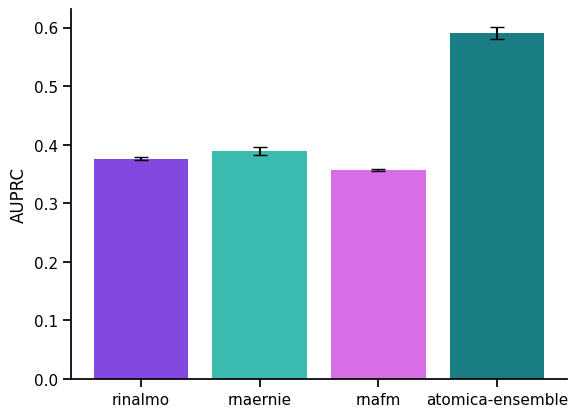

In [125]:
results = pd.concat([baseline_agg_results, atomica_metrics]).reset_index()
results.rename(columns={'index': 'model'}, inplace=True)
results = results[results['model'] != 'atomica']

# Plot using barplot
ax = sns.barplot(x='model', y=('auprc', 'mean'), data=results, capsize=0.2, palette=custom_colors)

# Manually add error bars using the values of mean and std for each model
x_positions = np.arange(len(results['model']))
y_means = results[('auprc', 'mean')].values
y_stds = results[('auprc', 'std')].values

ax.errorbar(
    x=x_positions,
    y=y_means,
    yerr=y_stds,
    fmt='none',
    c='black',
    capsize=5,
    elinewidth=1.5
)

ax.set_xticks(x_positions)
ax.set_xticklabels(results['model'])
sns.despine()
ax.set_ylabel('AUPRC')
ax.set_xlabel('')
plt.show()

### Grouped scores by id

In [126]:
atomica_results['pred_bin'] = ensemble_pred >= best_t

atomica_results['correct'] = atomica_results['label'] == atomica_results['pred_bin']
balanced_acc = atomica_results.groupby('id')['correct'].mean().mean()

atomica_results['baseline_correct'] = atomica_results['label'] == 0
baseline_acc = atomica_results.groupby('id')['baseline_correct'].mean().mean()

print(balanced_acc, baseline_acc)

0.7491575746522185 0.6970169462442661


In [127]:
grouped = atomica_results.groupby('id')

auprcs, aurocs = [], []
baseline = []

for _, g in grouped:
    y_true = g['label']
    y_pred = g['pred']
    # skip if only one class is present (AUROC undefined)
    if len(set(y_true)) > 1:
        precision, recall, thresholds = precision_recall_curve(y_true, y_pred)
        auprc = auc(recall, precision)
        auroc = roc_auc_score(y_true, y_pred)
        auprcs.append(auprc)
        aurocs.append(auroc)
        baseline.append(np.mean(y_true))


mean_auprc = sum(auprcs) / len(auprcs)
mean_auroc = sum(aurocs) / len(aurocs)
mean_baseline = sum(baseline) / len(baseline)

print(f"Mean AUPRC: {mean_auprc:.4f}")
print(f"Mean AUROC: {mean_auroc:.4f}")
print(f"Baseline: {mean_baseline:.4f}")

Mean AUPRC: 0.6130
Mean AUROC: 0.5501
Baseline: 0.4230


# RNA-Site (SOTA)

RNA FM best metrics: `/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_tasks/models/RNAFM/RNA_Site/version_5/test_metrics.json`
* accuracy 0.9209
* balanced_accuracy 0.4995
* roc_auc 0.6639
* auprc 0.1375

RNAErnie best metrics: `/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_tasks/models/rnaernie/RNA_Site/version_0/test_metrics.json`
* accuracy: 0.9228
* balanced_accuracy: 0.5059
* roc_auc: 0.5980
* auprc: 0.1816

RiNAlmo best metrics: `/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_tasks/models/rinalmo/RNA_Site/version_22/test_metrics.json`
* accuracy: 0.9242,
* balanced_accuracy: 0.5283,
* roc_auc: 0.6887,
* auprc: 0.2197,

Ensembling does not help.




In [128]:
baselines = []
for baseline_model in ["rinalmo","rnafm","rnaernie"]:
    df = process_atomica_rnafm_mlp_results(f"{DATA_DIR}/{baseline_model}/RNA_Site/", "best_val_f1")
    df['baseline_model'] = baseline_model
    baselines.append(df)
baselines = pd.concat(baselines)
baseline_agg_results = baselines.groupby('baseline_model').agg({
    'accuracy': ['mean', 'std'],
    'balanced_accuracy': ['mean', 'std'],
    'roc_auc': ['mean', 'std'],
    'auprc': ['mean', 'std'],
})
baseline_agg_results

accuracy           balanced_accuracy             roc_auc  \
                    mean       std              mean       std      mean   
baseline_model                                                             
rinalmo         0.922520  0.001412          0.511166  0.003046  0.673028   
rnaernie        0.922828  0.001223          0.508625  0.012465  0.597660   
rnafm           0.921904  0.000000          0.500000  0.000000  0.682820   

                             auprc            
                     std      mean       std  
baseline_model                                
rinalmo         0.015329  0.186942  0.020545  
rnaernie        0.018456  0.161948  0.016411  
rnafm           0.012065  0.136566  0.002877

In [131]:
model_checkpoints = [
    f"{MODEL_DIR}/RNA_Site/models/version_10/checkpoint/epoch51_step2444.pt",
    f"{MODEL_DIR}/RNA_Site/models/version_28/checkpoint/epoch40_step1927.pt",
    f"{MODEL_DIR}/RNA_Site/models/version_29/checkpoint/epoch67_step3264.pt",
    f"{MODEL_DIR}/RNA_Site/models/version_30/checkpoint/epoch67_step3128.pt",
    f"{MODEL_DIR}/RNA_Site/models/version_31/checkpoint/epoch73_step3478.pt",
    f"{MODEL_DIR}/RNA_Site/models/version_32/checkpoint/epoch53_step2430.pt",
    f"{MODEL_DIR}/RNA_Site/models/version_33/checkpoint/epoch53_step2592.pt",
]

all_metrics = []
ensemble_prob = None
for model_checkpoint in model_checkpoints:
    atomica_results = get_atomica_results(model_checkpoint, "RNA_Site", split="test")
    if ensemble_prob is None:
        ensemble_prob = atomica_results['pred_probability']
    else:
        ensemble_prob += atomica_results['pred_probability']
    
    precision, recall, thresholds = precision_recall_curve(atomica_results['label'], atomica_results['pred_probability'])
    auprc = auc(recall, precision)
    metrics_dict = {
        'model': 'atomica',
        'checkpoint_path': model_checkpoint,
        'accuracy': np.mean(atomica_results['label'] == atomica_results['pred']),
        'roc_auc': roc_auc_score(atomica_results['label'], atomica_results['pred_probability']),
        'auprc': auprc,
    }
    all_metrics.append(metrics_dict)

ensemble_prob = np.stack(ensemble_prob) / len(model_checkpoints)

thresholds = np.linspace(0.0, 1.0, 101)  # e.g. test thresholds from 0.00 to 1.00
f1s = [f1_score(atomica_results['label'], (ensemble_prob >= t).astype(int)) for t in thresholds]
best_t = thresholds[np.argmax(f1s)]
best_f1 = max(f1s)

ensemble_pred = (ensemble_prob > best_f1).astype(int)
precision, recall, thresholds = precision_recall_curve(atomica_results['label'], ensemble_prob)
auprc = auc(recall, precision)
metrics_dict = {
    'model': 'atomica-ensemble',
    'checkpoint_path': 'ensemble',
    'accuracy': np.mean(atomica_results['label'] == ensemble_pred),
    'roc_auc': roc_auc_score(atomica_results['label'], ensemble_prob),
    'auprc': auprc,
}
all_metrics.append(metrics_dict)

all_metrics = pd.DataFrame(all_metrics)
atomica_metrics = all_metrics.groupby('model').agg({
    'accuracy': ['mean', 'std'],
    'roc_auc': ['mean', 'std'],
    'auprc': ['mean', 'std'],
})

atomica_metrics.loc['atomica-ensemble', ('accuracy', 'std')] = atomica_metrics.loc['atomica', ('accuracy', 'std')] 
atomica_metrics.loc['atomica-ensemble', ('roc_auc', 'std')] = atomica_metrics.loc['atomica', ('roc_auc', 'std')] 
atomica_metrics.loc['atomica-ensemble', ('auprc', 'std')] = atomica_metrics.loc['atomica', ('auprc', 'std')] 
display(atomica_metrics)

accuracy             roc_auc               auprc          
                      mean       std      mean       std      mean       std
model                                                                       
atomica           0.919312  0.006474  0.630738  0.036361  0.158785  0.033969
atomica-ensemble  0.921759  0.006474  0.697021  0.036361  0.238005  0.033969

/tmp/ipykernel_2161207/4139117717.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='model', y=('auprc', 'mean'), data=results, capsize=0.2, palette=custom_colors)
/tmp/ipykernel_2161207/4139117717.py:6: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  ax = sns.barplot(x='model', y=('auprc', 'mean'), data=results, capsize=0.2, palette=custom_colors)


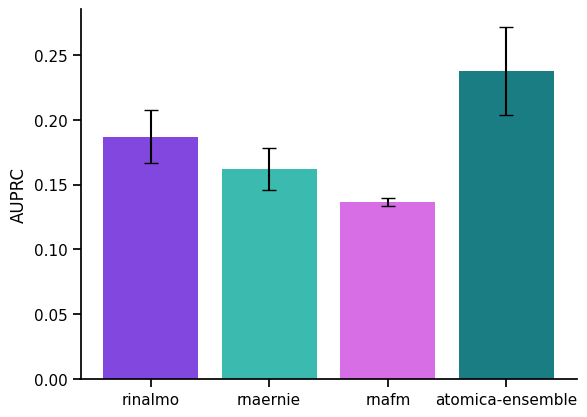

In [134]:
results = pd.concat([baseline_agg_results, atomica_metrics]).reset_index()
results.rename(columns={'index': 'model'}, inplace=True)
results = results[results['model'] != 'atomica']

# Plot using barplot
ax = sns.barplot(x='model', y=('auprc', 'mean'), data=results, capsize=0.2, palette=custom_colors)

# Manually add error bars using the values of mean and std for each model
x_positions = np.arange(len(results['model']))
y_means = results[('auprc', 'mean')].values
y_stds = results[('auprc', 'std')].values

ax.errorbar(
    x=x_positions,
    y=y_means,
    yerr=y_stds,
    fmt='none',
    c='black',
    capsize=5,
    elinewidth=1.5
)

ax.set_xticks(x_positions)
ax.set_xticklabels(results['model'])
sns.despine()
ax.set_ylabel('AUPRC')
ax.set_xlabel('')
plt.show()

### Grouped scores by id

In [95]:
ensemble_results = {
    'id': atomica_results['id'].apply(lambda x: "_".join(x.split('_')[0:2])),
    'pred': ensemble_pred,
    'label': atomica_results['label'],
    'pred_probability': ensemble_prob,
}
ensemble_results = pd.DataFrame(ensemble_results)
grouped = ensemble_results.groupby('id')

auprcs, aurocs = [], []
baseline = []

for _, g in grouped:
    y_true = g['label']
    y_pred = g['pred']
    # skip if only one class is present (AUROC undefined)
    if len(set(y_true)) > 1:
        precision, recall, thresholds = precision_recall_curve(y_true, y_pred)
        auprc = auc(recall, precision)
        auroc = roc_auc_score(y_true, y_pred)
        auprcs.append(auprc)
        aurocs.append(auroc)
        baseline.append(np.mean(y_true))


mean_auprc = sum(auprcs) / len(auprcs)
mean_auroc = sum(aurocs) / len(aurocs)
mean_baseline = sum(baseline) / len(baseline)

print(f"Mean AUPRC: {mean_auprc:.4f}")
print(f"Mean AUROC: {mean_auroc:.4f}")
print(f"Baseline: {mean_baseline:.4f}")

Mean AUPRC: 0.5071
Mean AUROC: 0.5430
Baseline: 0.1034


### Ensemble model
Is not useful for this task.

In [99]:
df = process_atomica_rnafm_mlp_results("/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/atomica_ensemble/RNA_Site/no_normalize_l2_no_use_layer_norm/",
                                      "best_val_f1", exclude_dropout=True)
df['model'] = 'atomica-rnafm-ensemble'
df = df.groupby('model').agg({
    'accuracy': ['mean', 'std'],
    'balanced_accuracy': ['mean', 'std'],
    'roc_auc': ['mean', 'std'],
    'auprc': ['mean', 'std'],
})
display(df)

accuracy           balanced_accuracy            \
                            mean       std              mean       std   
model                                                                    
atomica-rnafm-ensemble  0.906173  0.002829           0.56786  0.006423   

                         roc_auc               auprc            
                            mean       std      mean       std  
model                                                           
atomica-rnafm-ensemble  0.651004  0.009016  0.186427  0.003412